In [27]:
import numpy as np
from sklearn.datasets import fetch_california_housing
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

In [ ]:
#线性回归模型的定义(引入正则化L2)
class MyLR:
    def __init__(self, learing_rate=0.01, n_iters=1000, _lambda=0.05):
        self.lr = learing_rate
        self.n_iters = n_iters
        self.w = None
        self.b = None
        self.loss_history = []
        self._lambda = _lambda

    def trained(self, X, y):
        n_sampeles, n_features = X.shape
        self.w = np.zeros(n_features)
        self.b = 0
        for i in range(self.n_iters):
            y_pred = np.dot(X, self.w) + self.b
            dw = (1 / n_sampeles) * np.dot(X.T, (y_pred - y)) + (self._lambda / n_sampeles) * self.w
            db = (1 / n_sampeles) * np.sum(y_pred - y)
            self.w -= self.lr*dw
            self.b -= self.lr*db
            loss = np.mean((y_pred - y) ** 2) + (self._lambda / n_sampeles) * np.sum(self.w**2)
            self.loss_history.append(loss)
        return self
    
    def predict(self, X):
        y_pred = np.dot(X,self.w) + self.b
        return y_pred
    
    def get_w_b(self):
        return self.w, self.b

In [29]:
houseing = fetch_california_housing()
X = houseing.data
y = houseing.target
df = pd.DataFrame(
    houseing.data,
    columns=houseing.feature_names
)
#查看数据
df['Price'] = houseing.target

print(df.head())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  Price  
0    -122.23  4.526  
1    -122.22  3.585  
2    -122.24  3.521  
3    -122.25  3.413  
4    -122.25  3.422  


In [30]:
#对数据进行划分
feature_names = houseing.feature_names
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#标准化数据
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)#学习训练集的均值和方差，并对训练集进行标准化
X_test_scaled = scaler.transform(X_test)#不对测试集学习，防止测试集的信息泄露

#模型训练
model = MyLR(learing_rate=0.01, n_iters=1000)
model.trained(X_train_scaled, y_train)

y_pred_train = model.predict(X_train_scaled)
y_pred_test = model.predict(X_test_scaled)

#模型的评估
train_mse = mean_squared_error(y_train, y_pred_train)
test_mse = mean_squared_error(y_test, y_pred_test)
test_rmse = np.sqrt(test_mse)
test_mae = mean_absolute_error(y_test, y_pred_test)
test_r2 = r2_score(y_test, y_pred_test)

print(f"训练集 MSE : {train_mse:.6f}")
print(f"测试集 MSE : {test_mse:.6f}")
print(f"测试集 RMSE: {test_rmse:.6f}")
print(f"测试集 MAE : {test_mae:.6f}")
print(f"测试集 R²  : {test_r2:.6f}")

训练集 MSE : 0.547679
测试集 MSE : 0.567186
测试集 RMSE: 0.753117
测试集 MAE : 0.547676
测试集 R²  : 0.567169


/tmp/ipykernel_6758/4200325863.py:19: UserWarning: Glyph 36845 (\N{CJK UNIFIED IDEOGRAPH-8FED}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6758/4200325863.py:19: UserWarning: Glyph 20195 (\N{CJK UNIFIED IDEOGRAPH-4EE3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6758/4200325863.py:19: UserWarning: Glyph 27425 (\N{CJK UNIFIED IDEOGRAPH-6B21}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6758/4200325863.py:19: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6758/4200325863.py:19: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6758/4200325863.py:19: UserWarning: Glyph 32451 (\N{CJK UNIFIED IDEOGRAPH-7EC3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6758/4200325863.py:19: UserWarning: Glyph 25439 (\N{CJK UNIFIED IDEOGRAPH-635F}

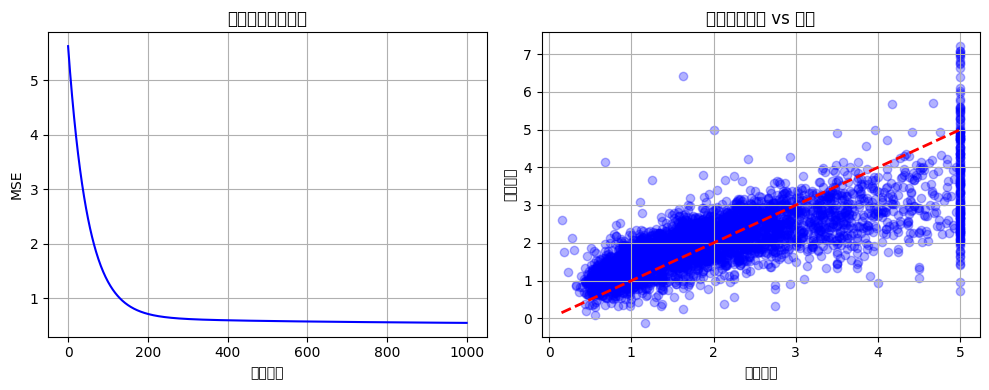

In [31]:
#可视化训练损失下降曲线
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(model.loss_history, color='blue')
plt.xlabel('迭代次数')
plt.ylabel('MSE')
plt.title('训练损失下降曲线')
plt.grid(True)

#可视化预测结果与真实值的关系
plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_test, alpha=0.3, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('真实房价')
plt.ylabel('预测房价')
plt.title('测试集：预测 vs 真实')
plt.grid(True)

plt.tight_layout()
plt.show()

In [32]:
#输出模型权重和偏置
weights, bias = model.get_w_b()
print("\n模型参数：")
for i, name in enumerate(feature_names):
    print(f"{name:12} 权重: {weights[i]:.6f}")
print(f"截距(bias): {bias:.6f}")


模型参数：
MedInc       权重: 0.828940
HouseAge     权重: 0.178531
AveRooms     权重: -0.137946
AveBedrms    权重: 0.156688
Population   权重: 0.016815
AveOccup     权重: -0.045228
Latitude     权重: -0.487050
Longitude    权重: -0.451466
截距(bias): 2.071857
